# Student Info
## Name: Jia Changyu
## English Name: Iris
## ID: C00292876

# 1. Introduction

The core objective of this experiment is to build and train a neural network model to perform an image classification task on the Fashion-MNIST dataset.

We designed and trained a Multilayer Perceptron (MLP) and a Convolutional Neural Network (CNN). The MLP uses fully connected layers to process flattened image pixels, while the CNN utilizes convolutional and pooling layers to directly capture the spatial hierarchical features of the image (e.g., edges and textures).

This experiment aims to evaluate and compare the accuracy and loss of these two models on the test set, visualize their learning process and prediction results, and delve into the main error patterns of the models to understand the strengths and limitations of different neural network architectures.

In [48]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from collections import Counter
from tensorflow.keras import layers
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')
import os

The data comes from the publicly available Kaggle dataset: Fashion-MNIST, containing 60,000 training images and 10,000 test images, covering 10 fashion categories. Each image is a 28×28 pixel grayscale image with a label from 0 to 9.

In [49]:
train_path = "../data/fashion-mnist_train.csv"
test_path = "../data/fashion-mnist_test.csv"

mnist_train = pd.read_csv(train_path)
mnist_test = pd.read_csv(test_path)

# 2. Initial Exploration

In [50]:
X_train = mnist_train.iloc[:, 1:].values
y_train = mnist_train.iloc[:, 0].values
X_test = mnist_test.iloc[:, 1:].values
y_test = mnist_test.iloc[:, 0].values

# Normalization: Scaling pixel values from 0-255 to 0-1.
X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

print(f"\nThe range of pixel values in the normalized training set: [{X_train_normalized.min():.3f}, {X_train_normalized.max():.3f}]")


The range of pixel values in the normalized training set: [0.000, 1.000]


In [51]:
class SimplePerceptron:
    def __init__(self, input_size, output_size):
        # Initialize the weight matrix with a shape of (input_size, output_size).
        self.weights = np.random.randn(input_size, output_size) * 0.01
        self.bias = np.zeros((1, output_size))
    
    def forward(self, x):
        z = np.dot(x, self.weights) + self.bias
        # Activation Functions
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def predict(self, x):
        probabilities = self.forward(x)
        return np.argmax(probabilities, axis=1)

# Initialize the network: 784 inputs, 10 outputs
input_size = 784
output_size = 10
simple_model = SimplePerceptron(input_size, output_size)

sample_input = X_train_normalized[:5]
predictions = simple_model.forward(sample_input)
print("\nThe predicted probability distribution of the first 5 images (each row sums up to 1):")
print(predictions)
print("\nThe predicted category is:", simple_model.predict(sample_input))
print("The actual label is:", y_train[:5])


The predicted probability distribution of the first 5 images (each row sums up to 1):
[[0.08621909 0.12154768 0.09907542 0.11581849 0.10424613 0.12140581
  0.10337637 0.09162468 0.0778801  0.07880624]
 [0.08502998 0.10178449 0.09975482 0.11204742 0.10389155 0.11580146
  0.09523871 0.10472459 0.09453328 0.08719369]
 [0.09420616 0.09983744 0.09817006 0.10699068 0.10556775 0.12306423
  0.11911405 0.09826498 0.07387403 0.08091062]
 [0.11079089 0.09857848 0.10318388 0.11217108 0.10004704 0.10687456
  0.10344667 0.10594253 0.07820155 0.08076331]
 [0.09873188 0.09784217 0.10228624 0.10756729 0.10675201 0.10122411
  0.11500111 0.10782797 0.07729868 0.08546854]]

The predicted category is: [1 5 5 3 6]
The actual label is: [2 9 6 0 3]


It shows the detailed prediction results of the model for the first 5 test samples: Among the 5 predictions, only the second one was correct.


Data augmentation examples (enhanced versions of the first 5 images)：


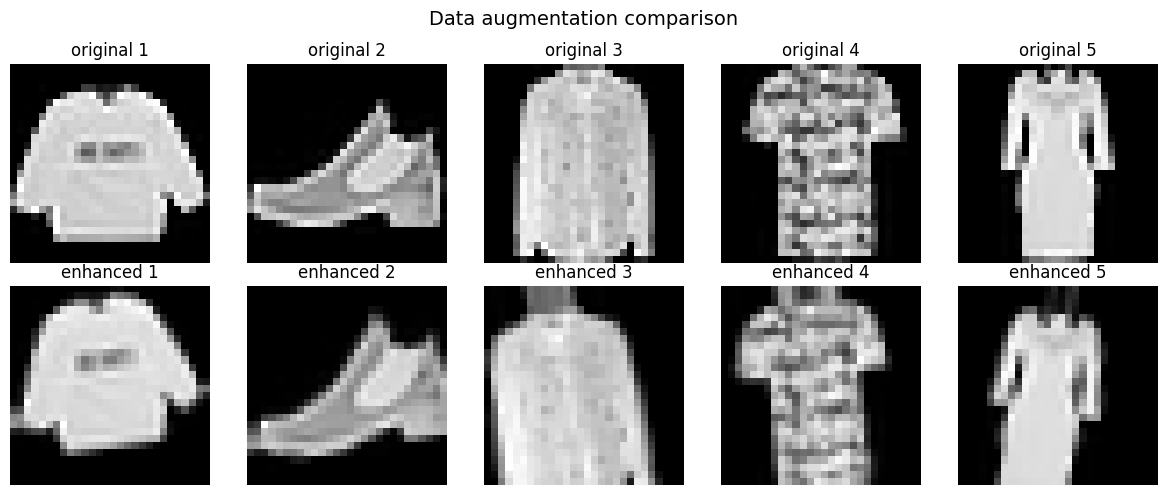

In [52]:
X_train_images = X_train_normalized.reshape(-1, 28, 28, 1)

# Create a data augmenter (with minor rotation, translation, and scaling)
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
)

print("\nData augmentation examples (enhanced versions of the first 5 images)：")
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    original_img = X_train_images[i].reshape(28, 28)
    augmented_img = datagen.random_transform(X_train_images[i]).reshape(28, 28)
    
    axes[0, i].imshow(original_img, cmap='gray')
    axes[0, i].set_title(f"original {i+1}")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(augmented_img, cmap='gray')
    axes[1, i].set_title(f"enhanced {i+1}")
    axes[1, i].axis('off')
plt.suptitle("Data augmentation comparison", fontsize=14)
plt.tight_layout()
plt.show()

# 3. Model Training

### 3.1 Multilayer Perceptron (MLP) neural network built using Keras.

In [53]:
# Building Multi-Layer Neural Network with Keras
model = keras.Sequential([
    # Input Layer: Input 784 one-dimensional pixel points into the network
    keras.layers.Input(shape=(784,)),
    
    # The first hidden layer: 128 neurons, using the ReLU activation function
    keras.layers.Dense(128, activation='relu', name='hidden_layer_1'),
    
    # Dropout Layer: Preventing Overfitting
    keras.layers.Dropout(0.2, name='dropout_1'),
    
    # The second hidden layer: 64 neurons, using the ReLU activation function
    keras.layers.Dense(64, activation='relu', name='hidden_layer_2'),
    
    # Dropout Layer
    keras.layers.Dropout(0.2, name='dropout_2'),
    
    # Output layer: 10 neurons, using the Softmax activation function to obtain the probability of each class
    keras.layers.Dense(10, activation='softmax', name='output_layer')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nSummary of Model Structure:")
model.summary()


Summary of Model Structure:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

The neural network model structure for dataset construction consists of two fully connected layers and Dropout regularization, with a total of approximately 109K parameters. The purpose is to verify and confirm that it is suitable for subsequent image classification training.

In [54]:
# Training and Evaluation of Models
epochs = 10
batch_size = 32
validation_split = 0.2

print(f"\nStart training...")
print(f"Training parameters: epochs={epochs}, batch_size={batch_size}, validation_split={validation_split}")

history = model.fit(
    X_train_normalized, 
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=validation_split,
    verbose=1
)

print("\nEvaluating the model on the test set...")
test_loss, test_acc = model.evaluate(X_test_normalized, y_test, verbose=0)
print(f"Test set loss: {test_loss:.4f}")
print(f"Accuracy of the test set: {test_acc:.4f}")


Start training...
Training parameters: epochs=10, batch_size=32, validation_split=0.2
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7849 - loss: 0.6042 - val_accuracy: 0.8457 - val_loss: 0.4284
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8408 - loss: 0.4425 - val_accuracy: 0.8593 - val_loss: 0.3896
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8518 - loss: 0.4081 - val_accuracy: 0.8671 - val_loss: 0.3741
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8579 - loss: 0.3880 - val_accuracy: 0.8679 - val_loss: 0.3670
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8678 - loss: 0.3641 - val_accuracy: 0.8702 - val_loss: 0.3662
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8723 - loss: 0.3504 - val_accuracy: 0.8730 - val_loss: 0.3510
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8743 - loss: 0.3425 - val_accuracy: 0.8781 - val_loss: 0.3374
Epo

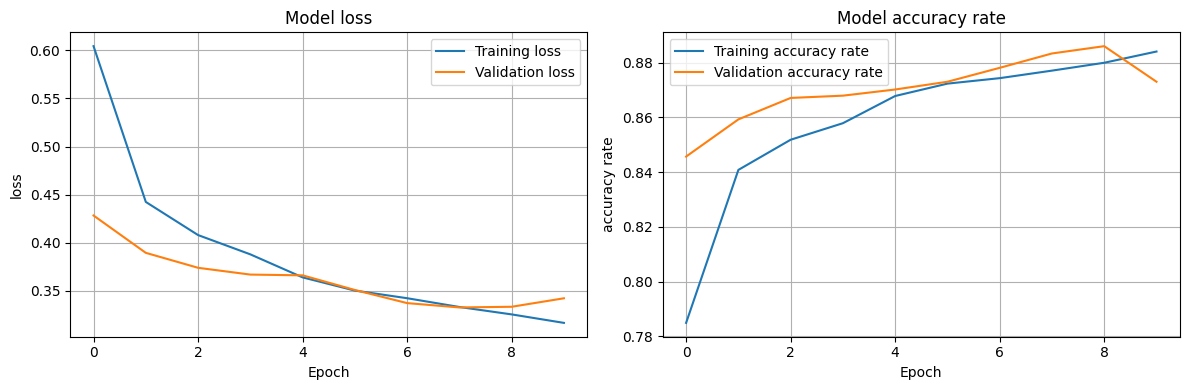

In [55]:
# Visualization of Training Process
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Draw the loss curve
    ax1.plot(history.history['loss'], label='Training loss')
    ax1.plot(history.history['val_loss'], label='Validation loss')
    ax1.set_title('Model loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('loss')
    ax1.legend()
    ax1.grid(True)
    
    # Draw the accuracy curve
    ax2.plot(history.history['accuracy'], label='Training accuracy rate')
    ax2.plot(history.history['val_accuracy'], label='Validation accuracy rate')
    ax2.set_title('Model accuracy rate')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('accuracy rate')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

The curves of loss and accuracy during training and validation both improved rapidly and then stabilized, showing that the model effectively converged and there was no overfitting.

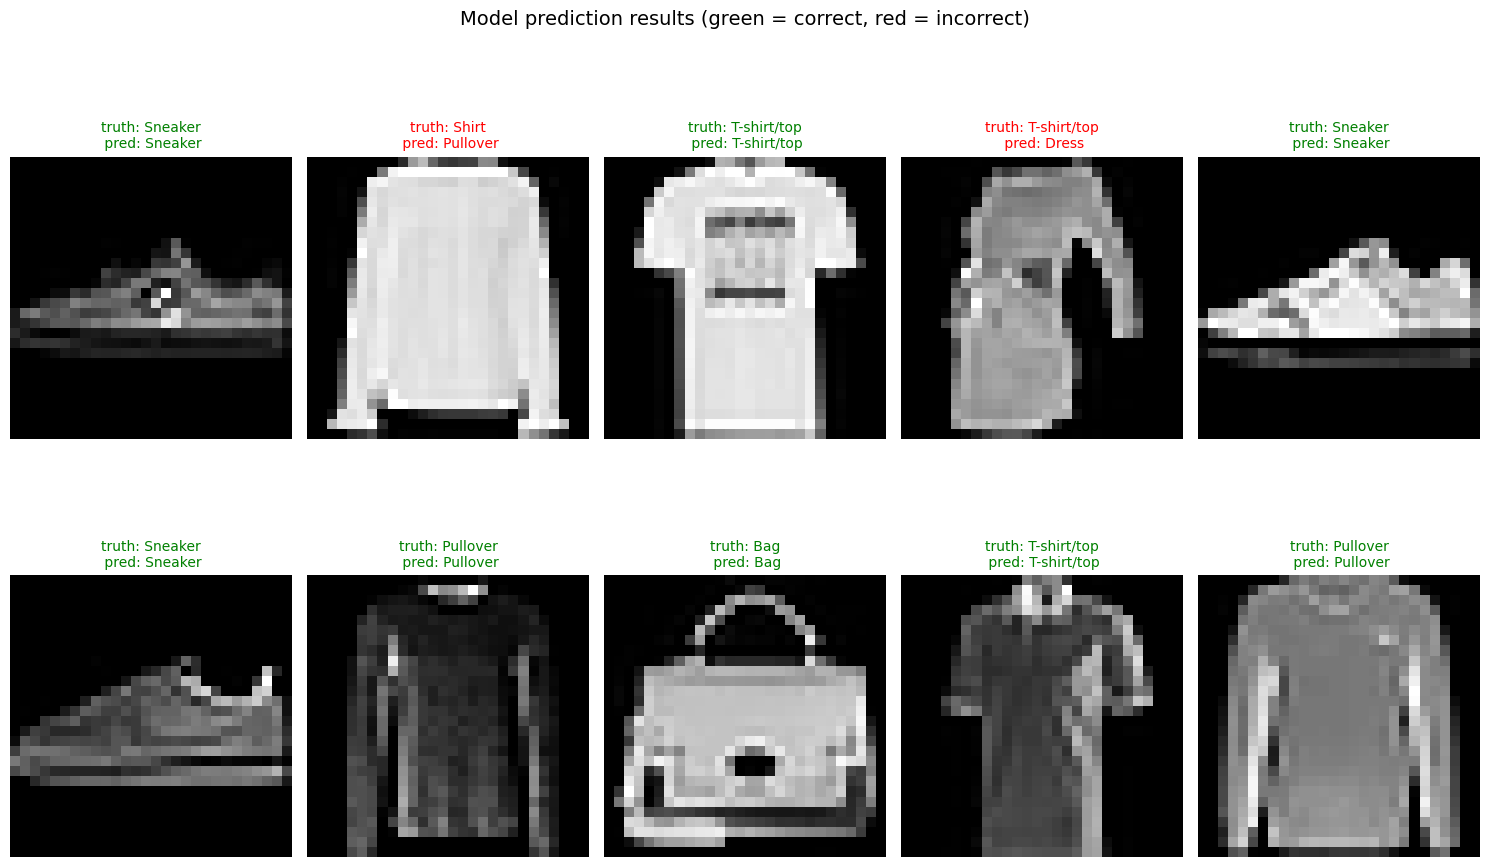

In [56]:
# Prediction
num_samples = 10
sample_indices = np.random.choice(len(X_test_normalized), num_samples, replace=False)
sample_images = X_test_normalized[sample_indices]
sample_labels = y_test[sample_indices]

predictions = model.predict(sample_images, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)

# Visualized Prediction Results
plt.figure(figsize=(15, 10))
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

for i in range(num_samples):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap='gray')
    
    color = 'green' if predicted_classes[i] == sample_labels[i] else 'red'
    
    plt.title(f"truth: {class_names[sample_labels[i]]}\n pred: {class_names[predicted_classes[i]]}", color=color, fontsize=10)
    plt.axis('off')

plt.suptitle('Model prediction results (green = correct, red = incorrect)', fontsize=14)
plt.tight_layout()
plt.show()

### 3.2 Convolutional Neural Network (CNN) technology

In [57]:
# Build a convolutional neural network (CNN)
# Reformat the data into the format required by CNN (number of samples, height, width, number of channels)
X_train_cnn = X_train_normalized.reshape(-1, 28, 28, 1)
if X_test is not None:
    X_test_cnn = X_test_normalized.reshape(-1, 28, 28, 1)

# Build a CNN model
cnn_model = Sequential([
    # The first convolutional layer
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv1'),
    MaxPooling2D((2, 2), name='pool1'),
    
    # The second convolutional layer
    Conv2D(64, (3, 3), activation='relu', name='conv2'),
    MaxPooling2D((2, 2), name='pool2'),
    
    # The third convolutional layer
    Conv2D(64, (3, 3), activation='relu', name='conv3'),
    
    # Flatten the layer and convert the 3D feature map into 1D
    Flatten(name='flatten'),
    
    # Fully connected layer (dense layer)
    Dense(64, activation='relu', name='dense1'),
    Dropout(0.5, name='dropout'),
    
    # Output layer (10 categories)
    Dense(10, activation='softmax', name='output')
])

# Compile model
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nSummary of CNN Model Structure:")
cnn_model.summary()


Summary of CNN Model Structure:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

The CNN model architecture (comprising 3 convolutional layers, with approximately 93K parameters in total) clearly presents the structure of each layer of the model, the changes in data flow, and the scale of parameters.

In [58]:
# Train the CNN model
# Use the data augmenter to train the CNN model
train_generator = datagen.flow(
    X_train_cnn, 
    y_train, 
    batch_size=32
)

# Train the CNN model
cnn_history = cnn_model.fit(
    train_generator,
    steps_per_epoch=len(X_train_cnn) // 32,
    epochs=10,
    validation_data=(X_test_cnn.reshape(-1, 28, 28, 1), y_test) if X_test is not None else None,
    verbose=1
)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.6823 - loss: 0.8551 - val_accuracy: 0.7890 - val_loss: 0.5199
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.7751 - loss: 0.5945 - val_accuracy: 0.8256 - val_loss: 0.4179
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8059 - loss: 0.5247 - val_accuracy: 0.8542 - val_loss: 0.3705
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8265 - loss: 0.4735 - val_accuracy: 0.8642 - val_loss: 0.3430
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8368 - loss: 0.4495 - val_accuracy: 0.8862 - val_loss: 0.3097
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8460 - loss: 0.4235 - val_accuracy: 0.8821 - val_loss: 0.3047
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8509 - loss: 0.4089 - val_accuracy: 0.8803 - val_loss: 0.3108
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8580 - loss: 

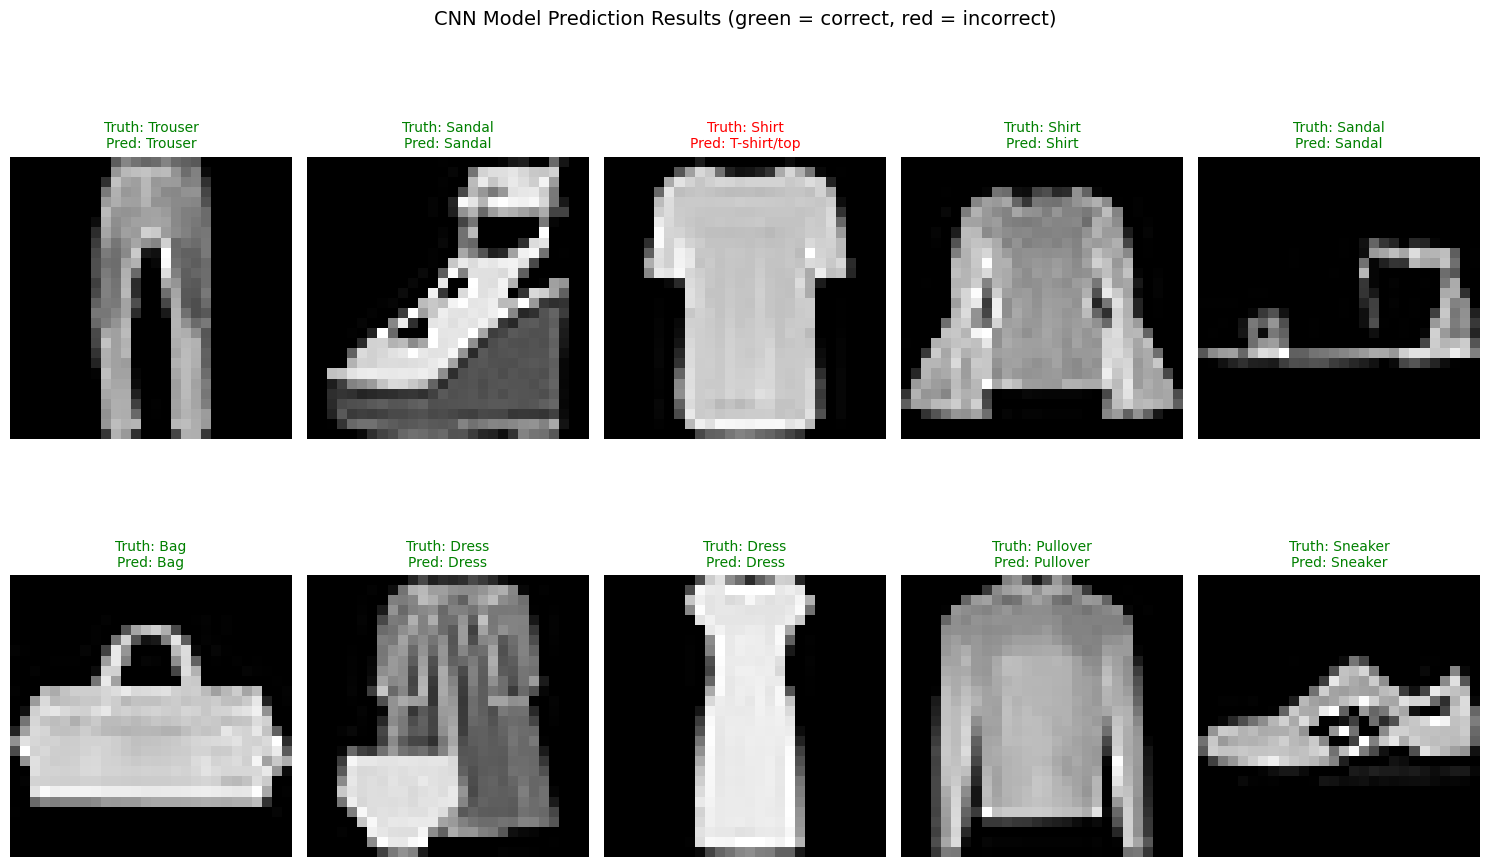

In [59]:
# Prediction
num_samples = 10
sample_indices = np.random.choice(len(X_test_normalized), num_samples, replace=False)
sample_images = X_test_cnn[sample_indices]
sample_labels = y_test[sample_indices]

predictions = cnn_model.predict(sample_images, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)

# Visualize the prediction results
plt.figure(figsize=(15, 10))
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

for i in range(num_samples):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap='gray')
    
    color = 'green' if predicted_classes[i] == sample_labels[i] else 'red'
    
    plt.title(f"Truth: {class_names[sample_labels[i]]}\nPred: {class_names[predicted_classes[i]]}", color=color, fontsize=10)
    plt.axis('off')

plt.suptitle('CNN Model Prediction Results (green = correct, red = incorrect)', fontsize=14)
plt.tight_layout()
plt.show()

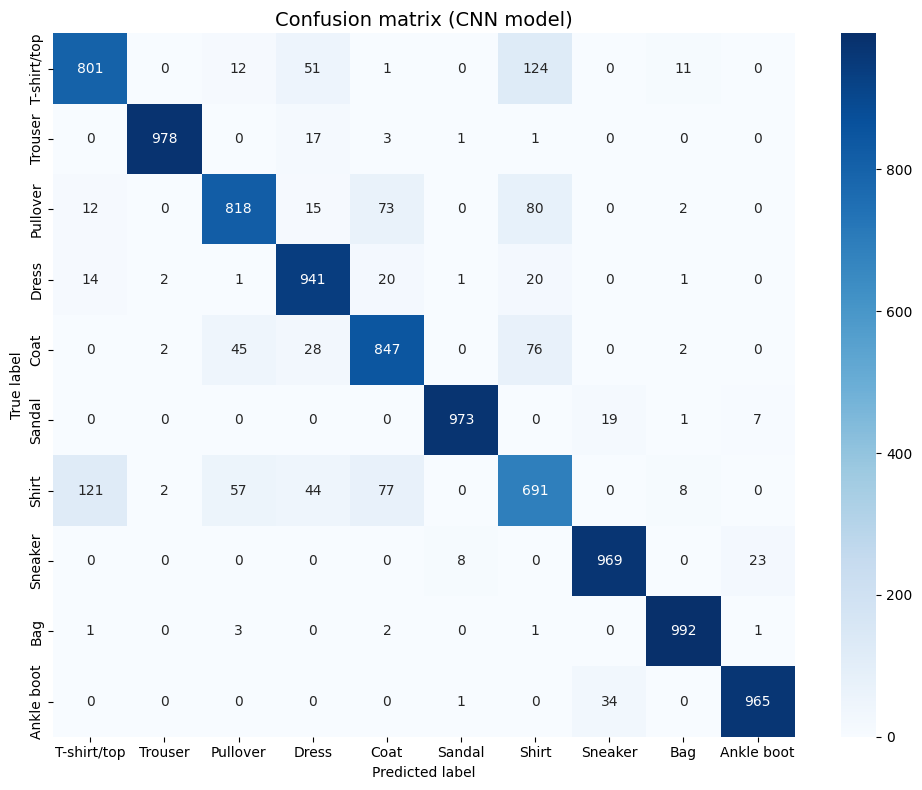


The most common misclassifications (the top 5)：
True: T-shirt/top     → Pred: Shirt           Count: 124
True: Shirt           → Pred: T-shirt/top     Count: 121
True: Pullover        → Pred: Shirt           Count: 80
True: Shirt           → Pred: Coat            Count: 77
True: Coat            → Pred: Shirt           Count: 76


In [60]:
# Confusion Matrix Analysis
if X_test is not None:
    # Obtain the prediction results of the CNN model
    cnn_predictions = cnn_model.predict(X_test_cnn, verbose=0)
    cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)
    cm = confusion_matrix(y_test, cnn_predicted_classes)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion matrix (CNN model)', fontsize=14)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()
    plt.show()
    print("\nThe most common misclassifications (the top 5)：")
    misclassified = []
    for i in range(len(y_test)):
        if y_test[i] != cnn_predicted_classes[i]:
            misclassified.append((y_test[i], cnn_predicted_classes[i]))
    
    top_misclass = Counter(misclassified).most_common(5)
    
    for (true, pred), count in top_misclass:
        print(f"True: {class_names[true]:<15} → Pred: {class_names[pred]:<15} Count: {count}")

The confusion matrix evaluated the classification performance of the CNN model for ten types of clothing and identified the easily confused categories. The overall accuracy of the model was high, but there were significant misclassifications in visually similar categories (such as "shirt" and "T-shirt", "coat").


Show the first layer's first 8 convolution kernels (k1 to k8):


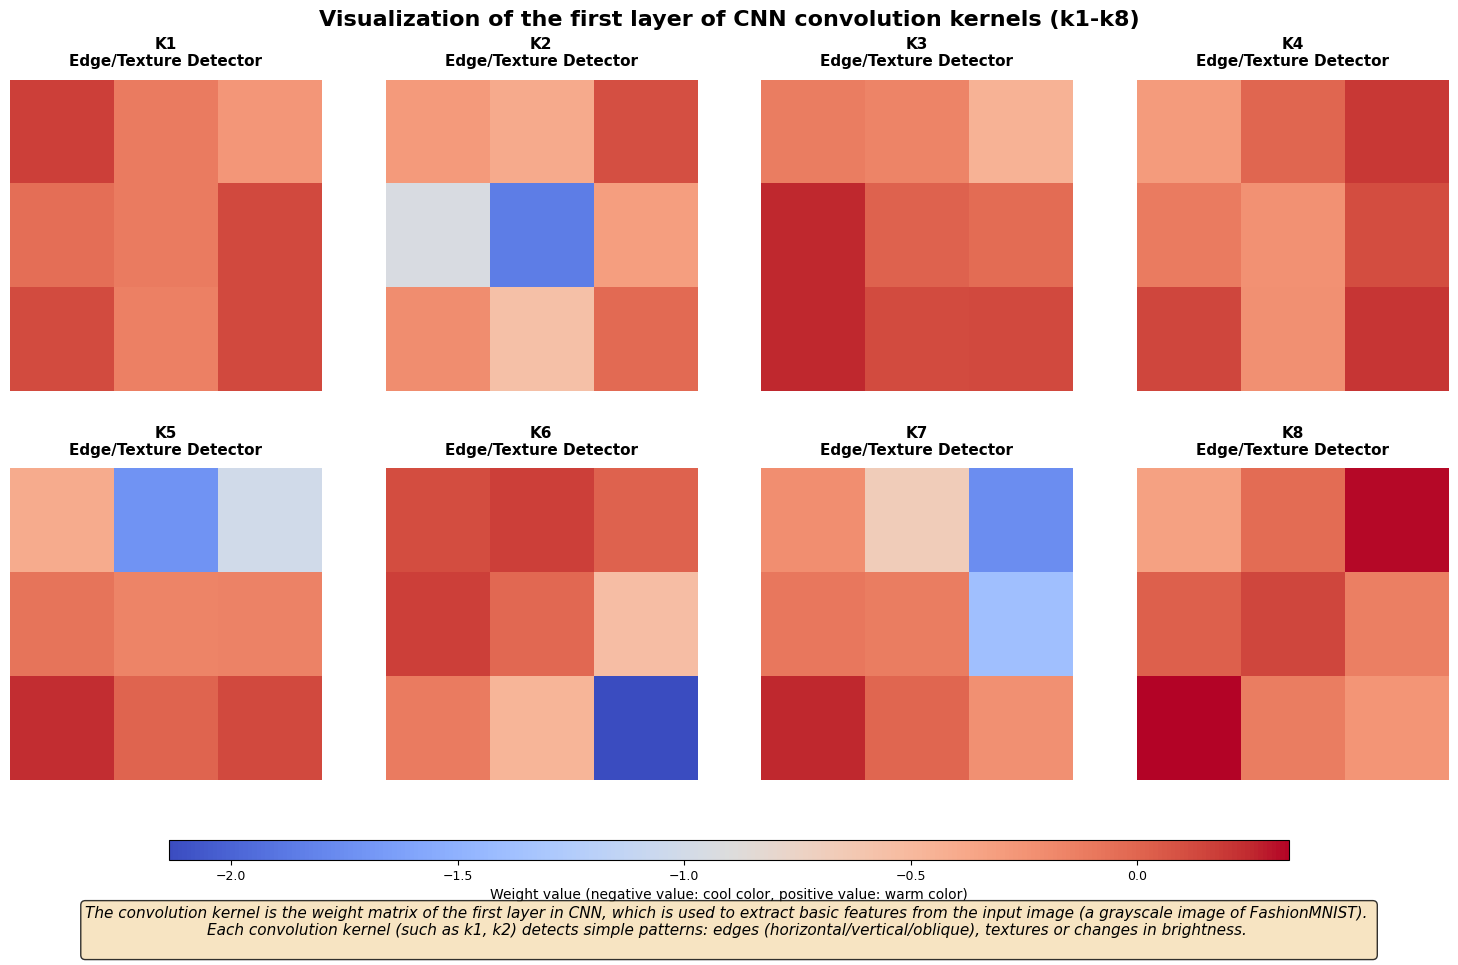

In [61]:
first_layer = cnn_model.layers[0]
weights = first_layer.get_weights()[0]

n_kernels = 8
rows = 2
cols = 4

print(f"\nShow the first layer's first {n_kernels} convolution kernels (k1 to k{n_kernels}):")

fig, axes = plt.subplots(rows, cols, figsize=(16, 10))
axes = axes.flatten()

vmin = weights[:, :, 0, :n_kernels].min()
vmax = weights[:, :, 0, :n_kernels].max()

im = None

for i in range(n_kernels):
    kernel = weights[:, :, 0, i]
    
    ax = axes[i]
    im = ax.imshow(kernel, cmap='coolwarm', vmin=vmin, vmax=vmax, interpolation='nearest')
    ax.axis('off')
    
    ax.set_title(f'K{i+1}\nEdge/Texture Detector', fontsize=11, pad=10, weight='bold')

for i in range(n_kernels, rows * cols):
    axes[i].axis('off')
    
cbar_ax = fig.add_axes([0.15, 0.12, 0.7, 0.02])
cbar = plt.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Weight value (negative value: cool color, positive value: warm color)', fontsize=10)
cbar.ax.tick_params(labelsize=9)

explanation = (
    "The convolution kernel is the weight matrix of the first layer in CNN, which is used to extract basic features from the input image (a grayscale image of FashionMNIST). \n"
    "Each convolution kernel (such as k1, k2) detects simple patterns: edges (horizontal/vertical/oblique), textures or changes in brightness. \n"
)

fig.text(0.5, 0.03, explanation, ha='center', fontsize=11, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), wrap=True)

plt.suptitle('Visualization of the first layer of CNN convolution kernels (k1-k8)', fontsize=16, y=0.97, weight='bold')

plt.subplots_adjust(left=0.05, right=0.95, top=0.90, bottom=0.20, wspace=0.2, hspace=0.25)

plt.show()

The eight convolutional kernels exhibit distinct patterns of weight distribution. There are no completely identical convolution kernels, indicating that the model has learned diverse feature detectors. However, the negative weights are significantly stronger than the positive weights, which may lead to some features being overly suppressed.

### Vision Transformer (ViT)

This code implements a Visual Transformer (ViT) model for image classification tasks. It segments an image into fixed-size image patches, converts them into a sequence through linear projection and positional encoding, extracts features through multiple transformer encoders, and finally outputs class probabilities through a multilayer perceptron (MLP) classification head.

In [64]:
# Vision Transformer (ViT)
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID',
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

def create_vit_classifier(
    input_shape=(28, 28, 1),
    patch_size=7,
    num_patches=16,
    projection_dim=64,
    num_heads=4,
    transformer_layers=6,
    mlp_head_units=[128, 64],
    num_classes=10,
):
    inputs = layers.Input(shape=input_shape)
    patches = Patches(patch_size)(inputs)
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        x2 = layers.Add()([attention_output, encoded_patches])

        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = mlp(x3, hidden_units=[projection_dim * 2, projection_dim], dropout_rate=0.1)
        encoded_patches = layers.Add()([x3, x2])

    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.GlobalAveragePooling1D()(representation)

    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.2)
    logits = layers.Dense(num_classes, activation='softmax')(features)

    model = tf.keras.Model(inputs=inputs, outputs=logits)
    return model

Compile using the Adam optimizer and cross-entropy loss function to output an overview of the model structure.

In [65]:
# Creating a ViT model
vit_model = create_vit_classifier(
    input_shape=(28, 28, 1),
    patch_size=7,
    num_patches=16,
    projection_dim=64,
    num_heads=4,
    transformer_layers=6,
    mlp_head_units=[128, 64],
    num_classes=10
)

vit_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

vit_model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches_1 (Patches) │ (None, None, 49)  │          0 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder_1     │ (None, 16, 64)    │      4,224 │ patches_1[0][0]   │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 64)    │        128 │ patch_encoder_1[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 16, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 64)    │        128 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 16, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 16, 128)   │          0 │ dense_17[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 16, 64)    │      8,256 │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 16, 64)    │          0 │ dense_18[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 16, 64)    │          0 │ dropout_22[0][0], │
│                     │                   │            │ add_12[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 64)    │        128 │ add_13[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 16, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_13[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 64)    │        128 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 16, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 16, 128)   │          0 │ dense_19[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 520,778 (1.99 MB)

 Trainable params: 520,778 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
# Training the ViT model
train_generator = datagen.flow(X_train_cnn, y_train, batch_size=64)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
]

vit_history = vit_model.fit(
    train_generator,
    steps_per_epoch=len(X_train_cnn) // 64,
    epochs=10,
    validation_data=(X_test_cnn, y_test),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 67s 61ms/step - accuracy: 0.5922 - loss: 1.0576 - val_accuracy: 0.7310 - val_loss: 0.6880 - learning_rate: 0.0010
Epoch 2/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7344 - loss: 0.6974 - val_accuracy: 0.7314 - val_loss: 0.6859 - learning_rate: 0.0010
Epoch 3/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 63s 67ms/step - accuracy: 0.7046 - loss: 0.7730 - val_accuracy: 0.7608 - val_loss: 0.6442 - learning_rate: 0.0010
Epoch 4/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7344 - loss: 0.8294 - val_accuracy: 0.7655 - val_loss: 0.6358 - learning_rate: 0.0010
Epoch 5/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 64s 69ms/step - accuracy: 0.7262 - loss: 0.7164 - val_accuracy: 0.7642 - val_loss: 0.6304 - learning_rate: 0.0010
Epoch 6/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7812 - loss: 0.6616 - val_accuracy: 0.7636 - val_loss: 0.6248 - learning_rate: 0.0010
Epoch 7/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 65s 69ms/step - accuracy: 0.7406 - loss: 0

<Figure size 600x600 with 0 Axes>

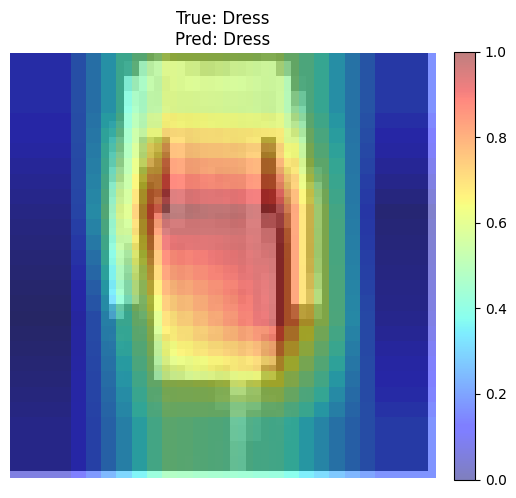

In [73]:
# Attention Heatmap Visualization
def create_vit_with_attention(input_shape=(28,28,1), patch_size=7, num_patches=16, projection_dim=64, num_heads=4, transformer_layers=6, num_classes=10):
    inputs = layers.Input(shape=input_shape)
    patches = Patches(patch_size)(inputs)
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        attention_output, scores = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1, return_attention_scores=True)
        x2 = layers.Add()([attention_output, encoded_patches])

        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = mlp(x3, hidden_units=[projection_dim*2, projection_dim], dropout_rate=0.1)
        encoded_patches = layers.Add()([x3, x2])

    last_features = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.GlobalAveragePooling1D()(last_features)
    features = mlp(representation, hidden_units=[128, 64], dropout_rate=0.2)
    logits = layers.Dense(num_classes, activation='softmax')(features)

    model = tf.keras.Model(inputs=inputs, outputs=[logits, last_features])
    return model

def plot_attention_heatmap(model, image, true_label=None, class_names=None, ax=None):
    logits, last_features = model.predict(image, verbose=0)
    pred_class = np.argmax(logits[0])

    classifier_layer = model.layers[-1]
    class_weights = classifier_layer.get_weights()[0]

    patch_importance = np.dot(last_features[0], class_weights[:, pred_class])
    grid_size = int(np.sqrt(patch_importance.shape[0]))
    importance_grid = patch_importance.reshape(grid_size, grid_size)

    importance_map = tf.image.resize(importance_grid[..., np.newaxis], (28, 28), method='bilinear')
    importance_map = importance_map.numpy().squeeze()
    importance_map = (importance_map - importance_map.min()) / (importance_map.max() - importance_map.min() + 1e-8)

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6,6))
    ax.imshow(image[0, :, :, 0], cmap='gray', alpha=0.7)
    im = ax.imshow(importance_map, cmap='jet', alpha=0.5, extent=(0,28,28,0))
    ax.set_title(f'True: {class_names[true_label] if true_label is not None else "?"}\nPred: {class_names[pred_class]}')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Create a model with attention output and load weights
vit_vis_model = create_vit_with_attention(
    input_shape=(28,28,1), patch_size=7, num_patches=16,
    projection_dim=64, num_heads=4, transformer_layers=6, num_classes=10
)

vit_vis_model.set_weights(vit_model.get_weights())

idx = 4
sample_image = X_test_cnn[idx:idx+1]
true_label = y_test[idx]
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(6,6))
plot_attention_heatmap(vit_vis_model, sample_image, true_label=true_label, class_names=class_names)
plt.show()

This heatmap visually illustrates the "focus" of the Vision Transformer model when recognizing images—warmer areas represent regions the model pays more attention to. As you can see, the model accurately focuses on the main silhouette of the dress, which explains why it makes accurate predictions consistent with the true label.

### Comparison of MLP and CNN


Model performance comparison:
Model type      Test loss    Test accuracy
--------------------------------------------------
MLP             0.3329      0.8748
CNN             0.2766      0.8975
ViT             0.5330      0.8004


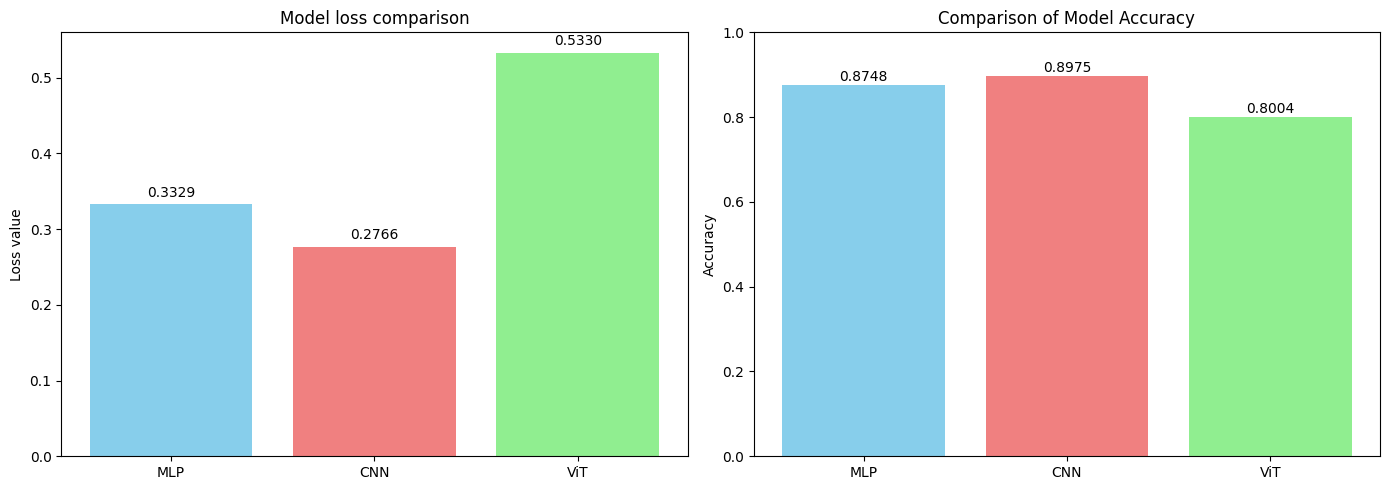

In [74]:
# Model Comparison Analysis
# Compare the performance of the three models
if X_test is not None:
    # Evaluation of Multi-Layer Perceptron (MLP)
    mlp_loss, mlp_acc = model.evaluate(X_test_normalized, y_test, verbose=0)
    
    # Evaluation of Convolutional Neural Network (CNN)
    cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
    
    # Evaluation of Vision Transformer (ViT)
    vit_loss, vit_acc = vit_model.evaluate(X_test_cnn, y_test, verbose=0)
    
    print("\nModel performance comparison:")
    print(f"{'Model type':<15} {'Test loss':<12} {'Test accuracy':<12}")
    print("-" * 50)
    print(f"{'MLP':<15} {mlp_loss:.4f}      {mlp_acc:.4f}")
    print(f"{'CNN':<15} {cnn_loss:.4f}      {cnn_acc:.4f}")
    print(f"{'ViT':<15} {vit_loss:.4f}      {vit_acc:.4f}")
    
    # Draw a comparative bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss Comparison
    models = ['MLP', 'CNN', 'ViT']
    losses = [mlp_loss, cnn_loss, vit_loss]
    colors = ['skyblue', 'lightcoral', 'lightgreen']
    axes[0].bar(models, losses, color=colors)
    axes[0].set_title('Model loss comparison')
    axes[0].set_ylabel('Loss value')
    for i, v in enumerate(losses):
        axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center')
    
    # Accuracy Comparison
    accuracies = [mlp_acc, cnn_acc, vit_acc]
    axes[1].bar(models, accuracies, color=colors)
    axes[1].set_title('Comparison of Model Accuracy')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim([0, 1])
    for i, v in enumerate(accuracies):
        axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center')
    
    plt.tight_layout()
    plt.show()

On the small-scale Fashion-MNIST dataset, CNN achieved the best results, while ViT performed the worst. This is mainly because ViT requires large-scale data to fully demonstrate its advantages in modeling global dependencies, and it is prone to overfitting on small-scale datasets, making it less effective than CNNs with local inductive bias.

# 4. Conclusion

Both neural network models achieved good performance on this task, demonstrating the effectiveness of deep learning in image classification. Convolutional Neural Networks (CNNs) performed best on this dataset, thanks to their inherent spatial locality, translation invariance, and inductive bias, properties that are highly effective for small-scale problems like Fashion-MNIST.

In contrast, while the Visual Transformer (ViT) is a powerful architecture for modeling long-range dependencies, its accuracy on this task is lower than that of CNNs, highlighting the need for larger datasets to fully realize its potential.